# 02 — Querying the REF API

This notebook shows how to talk to the public REF API: 
set up the client, discover diagnostics, retrieve metric values, and inspect an execution and its output files.

**Prerequisites:** [01 — REF concepts](01-ref-concepts.ipynb).

**What you need:** an internet connection.

## The API and its client

The REF API is documented with an [OpenAPI](https://www.openapis.org) schema.
You can browse the interactive docs at <https://api.climate-ref.org/docs>.

The `climate_ref_client` package is *generated* from that schema (see `scripts/generate_client.sh`). 
The `ref_tutorials` helper builds a client for us:

In [1]:
from ref_tutorials import get_client

client = get_client()

Each API endpoint is a function under `climate_ref_client.api`. 
The functions take a `client=` argument and have a `.sync(...)` method that performs the request and returns a parsed response. 

The payload is on the `.data` attribute.

## Listing diagnostics

In [2]:
from climate_ref_client.api.diagnostics import diagnostics_list

diagnostics = diagnostics_list.sync(client=client).data
len(diagnostics)

47

In [3]:
import pandas as pd

pd.DataFrame(
    {"provider": d.provider.slug, "slug": d.slug, "name": d.name}
    for d in sorted(diagnostics, key=lambda d: (d.provider.slug, d.slug))
)

,provider,slug,name
0,esmvaltool,climate-at-global-warming-levels,Climate at Global Warming Levels
1,esmvaltool,climate-drivers-for-fire,Climate Drivers for Fire
2,esmvaltool,cloud-radiative-effects,Cloud Radiative Effects
3,esmvaltool,cloud-scatterplots-cli-ta,Cloud-Temperature Scatterplots (cli vs ta)
4,esmvaltool,cloud-scatterplots-clivi-lwcre,Cloud-Radiation Scatterplots (clivi vs lwcre)
5,esmvaltool,cloud-scatterplots-clt-swcre,Cloud-Radiation Scatterplots (clt vs swcre)
6,esmvaltool,cloud-scatterplots-clwvi-pr,Cloud-Precipitation Scatterplots (clwvi vs pr)
7,esmvaltool,cloud-scatterplots-reference,Cloud Scatterplots for Reference dataset
8,esmvaltool,enso-basic-climatology,ENSO Basic Climatology
9,esmvaltool,enso-characteristics,ENSO Characteristics


## Retrieving metric values

REF stores two kinds of *metric values* (see `MetricValueType`):

- **scalar** — a single number for a given combination of dimensions (e.g. ECS per model).
- **series** — a 1-D array indexed along one axis (e.g. an annual-mean timeseries).

Diagnostics also publish **output files** (NetCDF data, figures, HTML) attached to each
execution. We cover those in the next section.

### Scalar values

We pick one diagnostic and ask the API for its scalar values.
Each value carries a set of *dimensions* (model, statistic, region, …) and a single number.

In [4]:
from climate_ref_client.api.diagnostics import diagnostics_list_metric_values
from climate_ref_client.models.metric_value_type import MetricValueType

diagnostic = next(d for d in diagnostics if d.execution_groups)

values = diagnostics_list_metric_values.sync(
    diagnostic.provider.slug,
    diagnostic.slug,
    value_type=MetricValueType.SCALAR,
    client=client,
).data
print(f"{diagnostic.name}: {len(values)} scalar metric values")
values[0]

Climate at Global Warming Levels: 44 scalar metric values


ScalarValue(dimensions=ScalarValueDimensions(additional_properties={'experiment_id': 'ssp126', 'metric': 'exceedance_year'}), value=2028.0, id=1, execution_group_id=1, execution_id=1, attributes=None, is_outlier=False, verification_status=<ScalarValueVerificationStatusType0.VERIFIED: 'verified'>, additional_properties={})

Raw metric values are awkward to work with. The `ref_tutorials` helper flattens them
into a tidy `pandas.DataFrame` — one column per dimension, plus a `value` column:

In [5]:
from ref_tutorials import metric_values_to_dataframe

df = metric_values_to_dataframe(values)
df.head(10)

,experiment_id,metric,value
0,ssp126,exceedance_year,2028.0
1,ssp126,exceedance_year,2040.0
2,ssp245,exceedance_year,2031.0
3,ssp245,exceedance_year,2044.0
4,ssp245,exceedance_year,2069.0
5,ssp245,exceedance_year,2081.0
6,ssp585,exceedance_year,2029.0
7,ssp585,exceedance_year,2036.0
8,ssp585,exceedance_year,2052.0
9,ssp585,exceedance_year,2068.0


From here it is ordinary pandas — filter, group, and summarise as you like:

In [6]:
df["value"].describe()

count      21.000000
mean     2045.952381
std        19.868257
min      2020.000000
25%      2031.000000
50%      2040.000000
75%      2060.000000
max      2082.000000
Name: value, dtype: float64

### Series values

Series values carry a 1-D array of numbers along a named index (typically time).
We ask the `global-mean-timeseries` diagnostic for one series and inspect it:

In [7]:
series = diagnostics_list_metric_values.sync(
    provider_slug="esmvaltool",
    diagnostic_slug="global-mean-timeseries",
    value_type=MetricValueType.SERIES,
    client=client,
    limit=50,
).data

one = next(v for v in series if v.dimensions.additional_properties.get("experiment_id") == "historical")
print("dimensions:", dict(one.dimensions.additional_properties))
print("index name:", one.index_name)
print("n points:  ", len(one.values))
print("attributes:", dict(one.attributes.additional_properties))

dimensions: {'source_id': 'ACCESS-CM2', 'experiment_id': 'historical', 'variable_id': 'tas', 'grid_label': 'gn', 'member_id': 'r1i1p1f1', 'region': 'global', 'statistic': 'annual mean'}
index name: time
n points:   165
attributes: {'calendar': 'proleptic_gregorian', 'caption': 'Annual global mean Near-Surface Air Temperature according to ACCESS-CM2.', 'index_long_name': 'time', 'index_name': 'time', 'index_standard_name': 'time', 'value_long_name': 'Near-Surface Air Temperature', 'value_standard_name': 'air_temperature', 'value_units': 'degrees_C', 'values_name': 'tas'}


Compared to a `ScalarValue`, a `SeriesValue` exposes:

- `values` — the list of numbers,
- `index` and `index_name` — the axis (often time stamps),
- `attributes` — CF-style metadata (units, long names, calendar).

It is trivial to drop into pandas and plot:

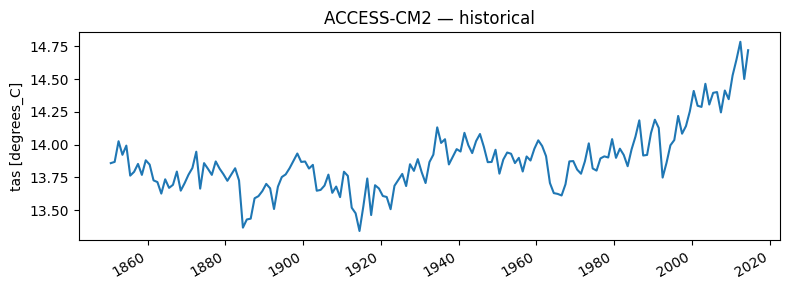

In [8]:
import pandas as pd

s = pd.Series(
    one.values,
    index=pd.to_datetime(one.index),
    name=one.attributes.additional_properties["values_name"],
)
units = one.attributes.additional_properties["value_units"]
ax = s.plot(figsize=(8, 3), title=f"{one.dimensions['source_id']} — {one.dimensions['experiment_id']}")
ax.set_ylabel(f"{s.name} [{units}]")
ax.figure.tight_layout()

## Output files (NetCDF, figures, HTML)

Beyond metric values, an execution publishes the *files* it produced. They come in three
flavours indicated by `output_type`:

- `data` — NetCDF (or CSV) data files,
- `plot` — figures (PNG, PDF),
- `html` — the CMEC bundle landing page.

We fetch one execution group and list a few of its outputs:

In [9]:
from climate_ref_client.api.executions import executions_get

execution = executions_get.sync(diagnostic.execution_groups[0], client=client)
print("execution key:", execution.key)

outputs = execution.latest_execution.outputs
for output in outputs[:10]:
    print("  ", output.filename)

execution key: cmip6_ssp126
   executions/recipe_20260305_234552/plots/gwl_mean_plots_pr/plot_gwl_stats/CMIP6_mm_mean_1.5.png
   executions/recipe_20260305_234552/plots/gwl_mean_plots_pr/plot_gwl_stats/CMIP6_mm_mean_2.0.png
   executions/recipe_20260305_234552/plots/gwl_mean_plots_pr/plot_gwl_stats/CMIP6_mm_stdev_1.5.png
   executions/recipe_20260305_234552/plots/gwl_mean_plots_pr/plot_gwl_stats/CMIP6_mm_stdev_2.0.png
   executions/recipe_20260305_234552/plots/gwl_mean_plots_tas/plot_gwl_stats/CMIP6_mm_mean_1.5.png
   executions/recipe_20260305_234552/plots/gwl_mean_plots_tas/plot_gwl_stats/CMIP6_mm_mean_2.0.png
   executions/recipe_20260305_234552/plots/gwl_mean_plots_tas/plot_gwl_stats/CMIP6_mm_stdev_1.5.png
   executions/recipe_20260305_234552/plots/gwl_mean_plots_tas/plot_gwl_stats/CMIP6_mm_stdev_2.0.png
   executions/recipe_20260305_234552/work/calculate_gwl_exceedance_years/gwl_exceedance_calculation/GWL_exceedance_years.csv
   executions/recipe_20260305_234552/work/gwl_mean_plot

Each output has an `output_type` and a `url`. Group them by type to see what is available:

In [10]:
from collections import Counter

Counter(o.output_type.value for o in outputs)

Counter({'data': 9, 'plot': 8, 'html': 1})

The `data` outputs are the most interesting for downstream analysis. We download the
first NetCDF file and open it with `xarray`:

In [11]:
import tempfile
from pathlib import Path

import requests
import xarray as xr

netcdfs = [o for o in outputs if o.filename.endswith(".nc")]
nc = netcdfs[0]
print("downloading", nc.filename)

response = requests.get(nc.url, timeout=60)
response.raise_for_status()

local = Path(tempfile.gettempdir()) / Path(nc.filename).name
local.write_bytes(response.content)

ds = xr.open_dataset(local)
ds

downloading executions/recipe_20260305_234552/work/gwl_mean_plots_pr/plot_gwl_stats/CMIP6_mm_mean_1.5.nc


<xarray.Dataset> Size: 541kB
Dimensions:     (lat: 180, lon: 360, bnds: 2)
Coordinates:
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
    cube_label  |S9276 9kB ...
    time        datetime64[ns] 8B ...
Dimensions without coordinates: bnds
Data variables:
    unknown     (lat, lon) float64 518kB ...
    lat_bnds    (lat, bnds) float64 3kB ...
    lon_bnds    (lon, bnds) float64 6kB ...
    time_bnds   (bnds) datetime64[ns] 16B ...
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.14.0rc1
    caption:      Multimodel mean of Precipitation at 1.5 $^\circ$ C

From here it is plain `xarray` — slice, regrid, plot, or combine with other datasets.
Notebook 03 uses this same pattern to build a publication-ready figure.

Text(0.5, 1.0, 'Zonal mean precipitation')

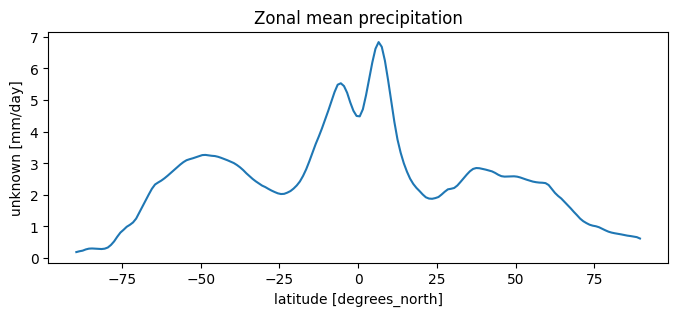

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))

# Note: the "unknown" variable in this case is precipitation
ds.mean("lon")["unknown"].plot()

plt.gca().set_title("Zonal mean precipitation")

## Recap

- Build a client with `get_client()`.
- API endpoints live under `climate_ref_client.api`; call `.sync(client=client)` and
  read `.data`.
- `diagnostics_list` discovers diagnostics; `diagnostics_list_metric_values` fetches
  their numbers — pass `MetricValueType.SCALAR` for single values or
  `MetricValueType.SERIES` for 1-D arrays.
- `metric_values_to_dataframe` tidies scalar values into pandas; series values expose
  `values`, `index`, and CF-style `attributes` you can hand straight to pandas/xarray.
- `executions_get` inspects a single run and exposes its output files (NetCDF, figures,
  HTML) via signed `url`s you can download.

**Next:** [03 — A publication-ready figure](03-publication-figure.ipynb).